Cloning into 'aprendizaje_profundo'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 176 (delta 91), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (176/176), 604.80 KiB | 12.34 MiB/s, done.
Resolving deltas: 100% (91/91), done.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,363 (13.14 KB)

 Trainable params: 3,363 (13.14 KB)

 Non-trainable params: 0 (0.00 B)


Entrenamiento finalizado en la época: 130


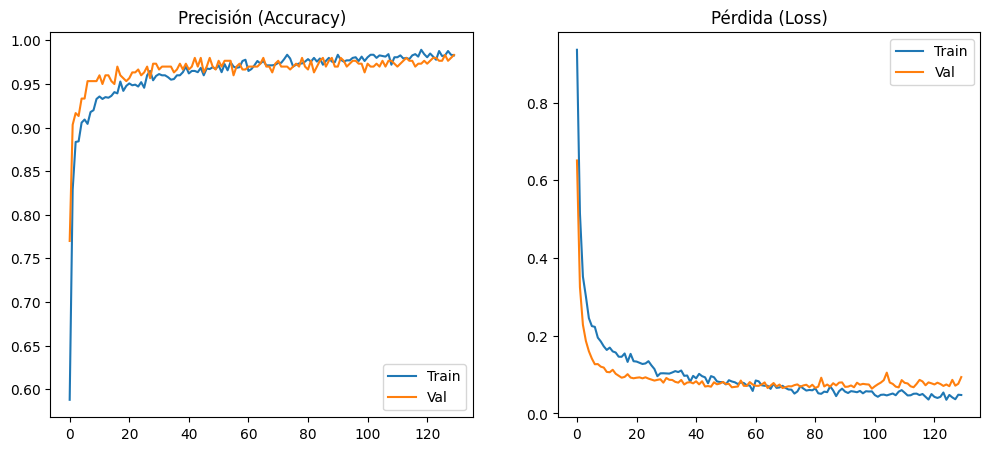

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Total Params:     3363
Train Accuracy:   0.9900
Val Accuracy:     0.9633
Test Accuracy:    0.9767
F1 Macro (Test):  0.9436


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import sys
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

!git clone https://github.com/macaspe4/aprendizaje_profundo.git

sys.path.append('/content/aprendizaje_profundo')

from modelos.modelo_complejos5 import crear_modelo

df = pd.read_csv('wfh_burnout_dataset.csv')
features = ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
            'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
            'isolation_index', 'fatigue_score']
X = df[features]
y = LabelEncoder().fit_transform(df['burnout_risk'])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

model = crear_modelo(X_train_sc.shape[1])
model.summary()

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = model.fit(X_train_sc, y_train,
                    validation_data=(X_val_sc, y_val),
                    epochs=300,
                    callbacks=[callback],
                    verbose=0)

print(f"\nEntrenamiento finalizado en la época: {len(history.history['loss'])}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Precisión (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Pérdida (Loss)')
plt.legend()
plt.show()

y_train_pred = np.argmax(model.predict(X_train_sc), axis=1)
y_val_pred = np.argmax(model.predict(X_val_sc), axis=1)
y_test_pred = np.argmax(model.predict(X_test_sc), axis=1)


print(f"Total Params:     {model.count_params()}")
print(f"Train Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Val Accuracy:     {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Test Accuracy:    {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 Macro (Test):  {f1_score(y_test, y_test_pred, average='macro'):.4f}")


### Conclusión
Este quinto modelo es el más completo y equilibrado del estudio. Tiene 4 capas ocultas y utiliza dos capas de Dropout (0.3 y 0.2) para reducir el sobreajuste. En total tiene 3.363 parámetros.

Gracias a esta combinación, el modelo mantiene una precisión alta pero más estable, con 99,00% en entrenamiento. En datos nuevos también obtiene muy buenos resultados: 97,67% de precisión en test y un F1 Macro de 0,9436, lo que indica que clasifica bien las tres categorías de riesgo de burnout.

Además, con Early Stopping el entrenamiento se detuvo en la época 130, justo cuando el modelo ya había alcanzado su mejor rendimiento. En general, este modelo resulta muy preciso y bastante robusto, por lo que sería una buena opción para usar en una aplicación real.